# 🧠 Graph-Transformer GeoAI — Phase 2: CNN Feature Extraction
**Goal:** Convert each 500m × 500m grid tile into a 256-dim feature vector using a pretrained CNN

```
GeoTIFF (19 bands) → Tile patches → ResNet encoder → Node feature matrix X [N × 256]
```

This node feature matrix becomes the input to the Graph Attention Network in Phase 3.


## 📦 Step 1: Install & Import Dependencies

In [ ]:
!pip install rasterio geopandas torch torchvision tqdm numpy matplotlib scikit-learn torch_geometric -q

import os
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
import rasterio
from rasterio.windows import from_bounds
from rasterio.enums import Resampling
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
import warnings
warnings.simplefilter('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✅ Using device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## 📂 Step 2: Mount Google Drive & Load Files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── Paths ──────────────────────────────────────────────────
DRIVE_DIR   = '/content/drive/MyDrive/GeoAI_Kogi'
TIFF_PATH   = f'{DRIVE_DIR}/kogi_features_100m.tif'   # from Phase 1 GEE export
NODES_PATH  = '/content/kogi_nodes.gpkg'
GRAPH_PATH  = '/content/kogi_graph_structure.pt'
OUTPUT_DIR  = '/content'

# ── Copy files from Drive to /content for faster I/O ──────
import shutil
for fname in ['kogi_nodes.gpkg', 'kogi_graph_structure.pt',
              'kogi_roads.gpkg', 'kogi_water.gpkg']:
    src = f'{DRIVE_DIR}/{fname}'
    dst = f'/content/{fname}'
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy(src, dst)
        print(f'  Copied: {fname}')

# ── Verify GeoTIFF ─────────────────────────────────────────
if not os.path.exists(TIFF_PATH):
    raise FileNotFoundError(
        f'GeoTIFF not found at {TIFF_PATH}\n'
        'Make sure the GEE export task finished (check Tasks tab in code.earthengine.google.com)'
    )

with rasterio.open(TIFF_PATH) as src:
    print(f'\n✅ GeoTIFF loaded:')
    print(f'   Bands     : {src.count}')
    print(f'   Resolution: {src.res[0]*111000:.0f}m × {src.res[1]*111000:.0f}m')
    print(f'   Size      : {src.width} × {src.height} pixels')
    print(f'   CRS       : {src.crs}')
    print(f'   Bounds    : {src.bounds}')

Mounted at /content/drive
  Copied: kogi_nodes.gpkg
  Copied: kogi_graph_structure.pt
  Copied: kogi_roads.gpkg

✅ GeoTIFF loaded:
   Bands     : 19
   Resolution: 100m × 100m
   Size      : 780 × 780 pixels
   CRS       : EPSG:4326
   Bounds    : BoundingBox(left=6.399598084067471, bottom=7.399422995292499, right=7.100284005680698, top=8.100108916905725)


## 🗺️ Step 3: Rebuild Study Area & Nodes (if session was reset)

In [ ]:
from shapely.geometry import box

# Rebuild STUDY_AREA dict (same as Phase 1)
STUDY_AREA = {
    'lon_min': 6.4,
    'lon_max': 7.1,
    'lat_min': 7.4,
    'lat_max': 8.1,
    'name': 'Lokoja_Kogi_Nigeria'
}

# Load or rebuild nodes GeoDataFrame
if os.path.exists(NODES_PATH):
    nodes_gdf = gpd.read_file(NODES_PATH)
    print(f'✅ Nodes loaded from file: {len(nodes_gdf)} tiles')
else:
    print('Rebuilding spatial grid...')
    TILE_SIZE_DEG = 0.0045
    lon_range = np.arange(STUDY_AREA['lon_min'], STUDY_AREA['lon_max'], TILE_SIZE_DEG)
    lat_range = np.arange(STUDY_AREA['lat_min'], STUDY_AREA['lat_max'], TILE_SIZE_DEG)
    tiles = []
    for i, lon in enumerate(lon_range):
        for j, lat in enumerate(lat_range):
            geom = box(lon, lat, lon + TILE_SIZE_DEG, lat + TILE_SIZE_DEG)
            tiles.append({
                'node_id': len(tiles), 'grid_col': i, 'grid_row': j,
                'centroid_lon': geom.centroid.x,
                'centroid_lat': geom.centroid.y,
                'geometry': geom
            })
    nodes_gdf = gpd.GeoDataFrame(tiles, crs='EPSG:4326')
    nodes_gdf.to_file(NODES_PATH, driver='GPKG')
    print(f'✅ Rebuilt: {len(nodes_gdf)} tiles')

N_NODES = len(nodes_gdf)
print(f'   N_NODES = {N_NODES}')

✅ Nodes loaded from file: 24336 tiles
   N_NODES = 24336


## 🔢 Step 4: Define Band Names & Extract Raw Features per Node

In [ ]:
# ============================================================
# BAND ORDER (matches Phase 1 feature stack):
#  0: VV         (S1 flood period)
#  1: VH         (S1 flood period)
#  2: flood_diff (VV change pre→flood)
#  3: B2  (Blue)       S2 wet
#  4: B3  (Green)      S2 wet
#  5: B4  (Red)        S2 wet
#  6: B8  (NIR)        S2 wet
#  7: B11 (SWIR1)      S2 wet
#  8: B12 (SWIR2)      S2 wet
#  9: NDVI             S2 wet
# 10: NDWI             S2 wet
# 11: MNDWI            S2 wet
# 12: EVI              S2 wet
# 13: NDVI_dry         S2 dry season
# 14: elevation        DEM
# 15: slope            DEM
# 16: aspect           DEM
# 17: twi_proxy        DEM
# 18: flood_risk_class LABEL
# ============================================================

BAND_NAMES = [
    'VV', 'VH', 'flood_diff',
    'B2', 'B3', 'B4', 'B8', 'B11', 'B12',
    'NDVI', 'NDWI', 'MNDWI', 'EVI', 'NDVI_dry',
    'elevation', 'slope', 'aspect', 'twi_proxy',
    'flood_risk_class'  # label band — index 18
]
FEATURE_BANDS = list(range(18))   # bands 0-17 are features
LABEL_BAND    = 18                # band 18 is the label
N_FEATURES    = len(FEATURE_BANDS)

print(f'Feature bands  : {N_FEATURES}')
print(f'Label band     : {BAND_NAMES[LABEL_BAND]}')

# ---- Extract per-node statistics from GeoTIFF ----
# For each node tile: compute mean of each band within the tile bounds
# This gives a [N_NODES × N_FEATURES] raw feature matrix

print(f'\nExtracting band statistics for {N_NODES} nodes...')

raw_features = np.zeros((N_NODES, N_FEATURES), dtype=np.float32)
labels       = np.zeros(N_NODES, dtype=np.int64)
valid_mask   = np.ones(N_NODES, dtype=bool)   # False if tile has no valid data

with rasterio.open(TIFF_PATH) as src:
    tiff_bounds = src.bounds

    for idx, row in tqdm(nodes_gdf.iterrows(), total=N_NODES, desc='Extracting tiles'):
        geom   = row.geometry
        bounds = geom.bounds  # (minx, miny, maxx, maxy)

        # Skip tiles outside the raster extent
        if (bounds[0] < tiff_bounds.left or bounds[2] > tiff_bounds.right or
            bounds[1] < tiff_bounds.bottom or bounds[3] > tiff_bounds.top):
            valid_mask[idx] = False
            continue

        try:
            window = from_bounds(
                bounds[0], bounds[1], bounds[2], bounds[3],
                transform=src.transform
            )
            # Read all bands for this window — shape [n_bands, h, w]
            tile_data = src.read(window=window, resampling=Resampling.bilinear)

            if tile_data.size == 0 or np.all(tile_data == 0):
                valid_mask[idx] = False
                continue

            # Feature bands: mean over spatial extent, ignore NaN/nodata
            for b in FEATURE_BANDS:
                band_data = tile_data[b].astype(np.float32)
                band_data[band_data == 0] = np.nan  # treat 0 as nodata
                mean_val = np.nanmean(band_data)
                raw_features[idx, b] = 0.0 if np.isnan(mean_val) else mean_val

            # Label band: mode (most common class in tile)
            label_data = tile_data[LABEL_BAND].astype(np.int32).flatten()
            label_data = label_data[label_data >= 0]   # remove nodata
            if len(label_data) > 0:
                labels[idx] = int(np.bincount(label_data).argmax())

        except Exception:
            valid_mask[idx] = False
            continue

n_valid = valid_mask.sum()
print(f'\n✅ Extraction complete')
print(f'   Valid nodes : {n_valid} / {N_NODES}')
print(f'   Raw features: {raw_features.shape}')
print(f'   Labels shape: {labels.shape}')

# Label distribution
unique, counts = np.unique(labels[valid_mask], return_counts=True)
class_names = {0: 'No Risk', 1: 'Low', 2: 'Medium', 3: 'High'}
print(f'\n   Label distribution:')
for u, c in zip(unique, counts):
    print(f'     Class {u} ({class_names.get(u, "?")}): {c} nodes ({100*c/n_valid:.1f}%)')

Feature bands  : 18
Label band     : flood_risk_class

Extracting band statistics for 24336 nodes...


Extracting tiles: 100%|██████████| 24336/24336 [00:38<00:00, 631.42it/s] 


✅ Extraction complete
   Valid nodes : 24025 / 24336
   Raw features: (24336, 18)
   Labels shape: (24336,)

   Label distribution:
     Class 0 (No Risk): 23282 nodes (96.9%)
     Class 1 (Low): 215 nodes (0.9%)
     Class 2 (Medium): 153 nodes (0.6%)
     Class 3 (High): 375 nodes (1.6%)


## 📐 Step 5: Build CNN Encoder (Modified ResNet18 for Multi-Band Input)

In [ ]:
# ============================================================
# ARCHITECTURE: Modified ResNet18
#
# Problem: standard ResNet expects 3-channel RGB input
# Our tiles have 18 spectral/topographic bands
#
# Solution: replace first conv layer to accept N_FEATURES channels
# Keep pretrained weights for all subsequent layers (transfer learning)
# Output: 256-dim feature vector per tile
# ============================================================

class MultiSpectralEncoder(nn.Module):
    """
    ResNet18 modified for multi-spectral satellite imagery.
    - First conv layer: 3 channels → N_FEATURES channels
    - Pretrained ImageNet weights for layers 2 onwards
    - Final FC replaced with 256-dim projection head
    """
    def __init__(self, n_input_channels=18, embed_dim=256):
        super().__init__()

        # Load pretrained ResNet18
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Replace first conv: 3 → n_input_channels
        # Average the pretrained RGB weights across all input channels (smart init)
        old_conv   = backbone.conv1
        new_conv   = nn.Conv2d(
            n_input_channels, 64,
            kernel_size=7, stride=2, padding=3, bias=False
        )
        with torch.no_grad():
            # Tile and average the 3-channel weights to n_input_channels
            w = old_conv.weight.mean(dim=1, keepdim=True)  # [64, 1, 7, 7]
            new_conv.weight = nn.Parameter(w.repeat(1, n_input_channels, 1, 1))

        backbone.conv1 = new_conv

        # Remove final FC layer — keep up to global avg pool
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])  # → [B, 512, 1, 1]

        # Projection head: 512 → embed_dim
        self.projection = nn.Sequential(
            nn.Flatten(),           # [B, 512]
            nn.Linear(512, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
            nn.Dropout(0.1)
        )

    def forward(self, x):
        features = self.encoder(x)       # [B, 512, 1, 1]
        return self.projection(features) # [B, embed_dim]


# Instantiate model
encoder = MultiSpectralEncoder(n_input_channels=N_FEATURES, embed_dim=256).to(DEVICE)

# Parameter count
total_params = sum(p.numel() for p in encoder.parameters())
trainable    = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print(f'✅ MultiSpectralEncoder built')
print(f'   Total parameters   : {total_params:,}')
print(f'   Trainable parameters: {trainable:,}')
print(f'   Input channels      : {N_FEATURES}')
print(f'   Output embed dim    : 256')

# Test with dummy input
dummy = torch.randn(4, N_FEATURES, 64, 64).to(DEVICE)  # batch of 4 tiles
with torch.no_grad():
    out = encoder(dummy)
print(f'   Forward pass test   : input {list(dummy.shape)} → output {list(out.shape)} ✅')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]


✅ MultiSpectralEncoder built
   Total parameters   : 11,355,392
   Trainable parameters: 11,355,392
   Input channels      : 18
   Output embed dim    : 256
   Forward pass test   : input [4, 18, 64, 64] → output [4, 256] ✅


## 🔲 Step 6: Build Tile Dataset for CNN

In [ ]:
from torch.utils.data import Dataset, DataLoader

# ============================================================
# TILE DATASET
# For the CNN we need actual 2D image patches (not just means)
# Each tile → 64×64 pixel patch across all 18 bands
# ============================================================

PATCH_SIZE = 64  # pixels per tile for CNN input

class TileDataset(Dataset):
    """
    Reads satellite image patches for each graph node from the GeoTIFF.
    Returns normalized 18-band patches of shape [18, 64, 64].
    """
    def __init__(self, nodes_gdf, tiff_path, valid_mask,
                 feature_bands, patch_size=64, band_stats=None):
        self.nodes      = nodes_gdf.reset_index(drop=True)
        self.tiff_path  = tiff_path
        self.valid_mask = valid_mask
        self.feat_bands = feature_bands
        self.patch_size = patch_size
        self.band_stats = band_stats  # (mean, std) for normalization
        self.valid_ids  = np.where(valid_mask)[0]

    def __len__(self):
        return len(self.valid_ids)

    def __getitem__(self, idx):
        node_idx = self.valid_ids[idx]
        row      = self.nodes.iloc[node_idx]
        bounds   = row.geometry.bounds   # (minx, miny, maxx, maxy)

        with rasterio.open(self.tiff_path) as src:
            window = from_bounds(
                bounds[0], bounds[1], bounds[2], bounds[3],
                transform=src.transform
            )
            # Read feature bands only, resample to PATCH_SIZE × PATCH_SIZE
            patch = src.read(
                indexes=[b + 1 for b in self.feat_bands],  # rasterio is 1-indexed
                window=window,
                out_shape=(len(self.feat_bands), self.patch_size, self.patch_size),
                resampling=Resampling.bilinear
            ).astype(np.float32)

        # Replace NaN/inf
        patch = np.nan_to_num(patch, nan=0.0, posinf=0.0, neginf=0.0)

        # Normalize per-band using dataset statistics
        if self.band_stats is not None:
            means, stds = self.band_stats
            for b in range(len(self.feat_bands)):
                std = stds[b] if stds[b] > 1e-6 else 1.0
                patch[b] = (patch[b] - means[b]) / std

        return torch.tensor(patch, dtype=torch.float32), node_idx


# ---- Compute per-band normalization stats from raw_features ----
valid_feats = raw_features[valid_mask]
band_means  = valid_feats.mean(axis=0)
band_stds   = valid_feats.std(axis=0) + 1e-6

print(f'Band normalization stats computed from {valid_mask.sum()} valid nodes')
print(f'  Sample — Band 0 (VV): mean={band_means[0]:.3f}, std={band_stds[0]:.3f}')
print(f'  Sample — Band 9 (NDVI): mean={band_means[9]:.3f}, std={band_stds[9]:.3f}')

# ---- Create Dataset & DataLoader ----
dataset = TileDataset(
    nodes_gdf   = nodes_gdf,
    tiff_path   = TIFF_PATH,
    valid_mask  = valid_mask,
    feature_bands = FEATURE_BANDS,
    patch_size  = PATCH_SIZE,
    band_stats  = (band_means, band_stds)
)

loader = DataLoader(dataset, batch_size=64, shuffle=False,
                    num_workers=2, pin_memory=True)

print(f'\n✅ TileDataset ready')
print(f'   Tiles in dataset : {len(dataset)}')
print(f'   Batch size       : 64')
print(f'   Patch shape      : [18, {PATCH_SIZE}, {PATCH_SIZE}]')
print(f'   N batches        : {len(loader)}')

Band normalization stats computed from 24025 valid nodes
  Sample — Band 0 (VV): mean=-8.250, std=2.071
  Sample — Band 9 (NDVI): mean=0.044, std=0.169

✅ TileDataset ready
   Tiles in dataset : 24025
   Batch size       : 64
   Patch shape      : [18, 64, 64]
   N batches        : 376


## 👁️ Step 7: Visualize Sample Tiles

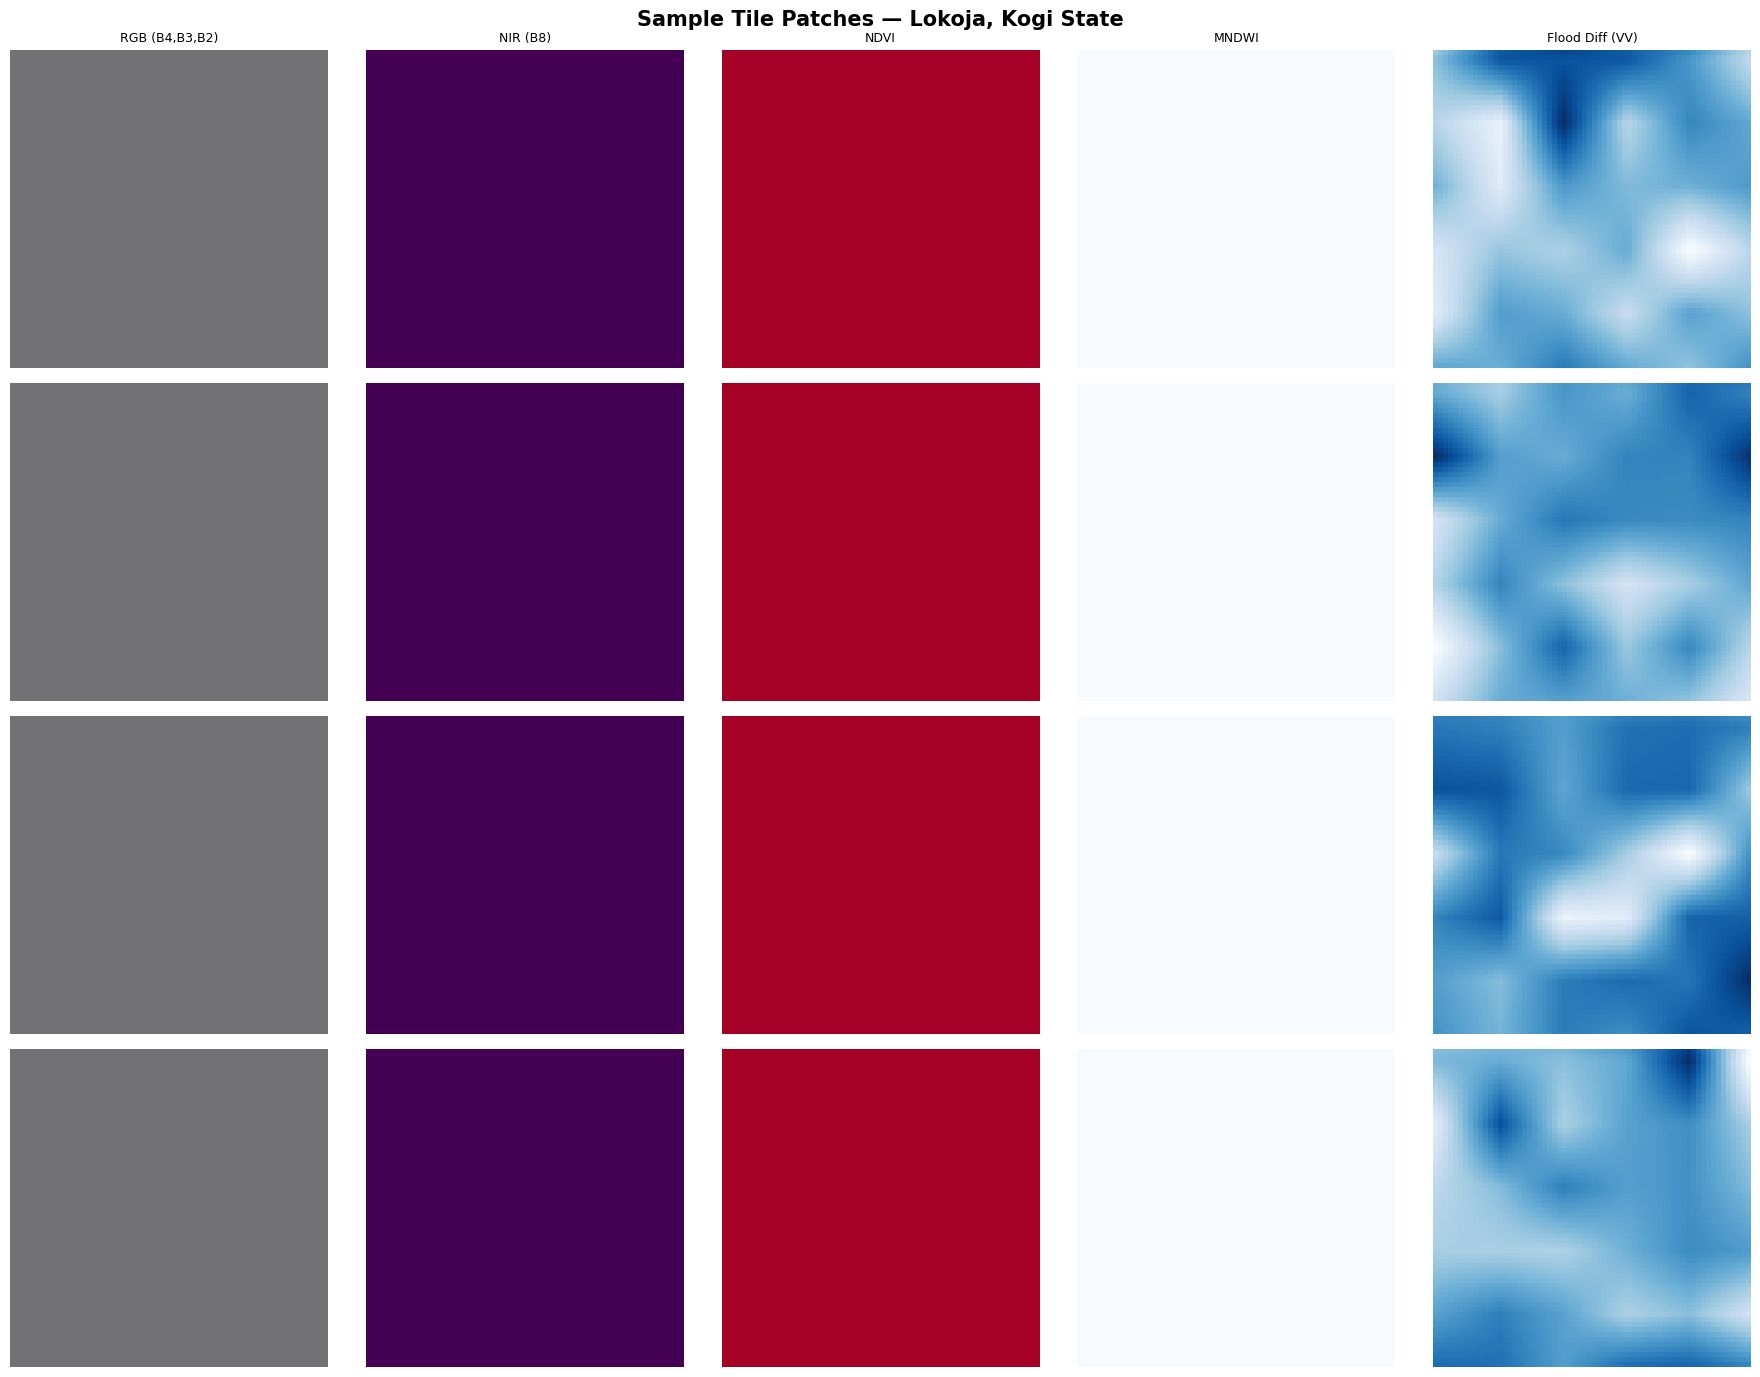

✅ Sample tiles visualized


In [ ]:
# Visualize a few sample tiles — RGB composite + NDVI + flood_diff
sample_patches, sample_ids = next(iter(loader))

fig, axes = plt.subplots(4, 5, figsize=(18, 14))
fig.suptitle('Sample Tile Patches — Lokoja, Kogi State', fontsize=15, fontweight='bold')

band_idx = {
    'RGB (B4,B3,B2)': [5, 4, 3],   # Red, Green, Blue
    'NIR (B8)': 6,
    'NDVI': 9,
    'MNDWI': 11,
    'Flood Diff (VV)': 2
}

for row_i, tile_idx in enumerate(range(min(4, len(sample_patches)))):
    patch = sample_patches[tile_idx].numpy()   # [18, 64, 64]

    for col_i, (band_name, bidx) in enumerate(band_idx.items()):
        ax = axes[row_i, col_i]

        if isinstance(bidx, list):  # RGB composite
            rgb = np.stack([patch[b] for b in bidx], axis=-1)
            # Clip to [-2, 2] std range for display
            rgb = np.clip((rgb + 2) / 4, 0, 1)
            ax.imshow(rgb)
        else:
            band_data = patch[bidx]
            cmap = 'RdYlGn' if 'NDVI' in band_name else \
                   'Blues'  if 'MNDWI' in band_name or 'Flood' in band_name else \
                   'viridis'
            ax.imshow(band_data, cmap=cmap)

        ax.set_title(band_name if row_i == 0 else '', fontsize=9)
        ax.set_ylabel(f'Tile {sample_ids[tile_idx].item()}' if col_i == 0 else '', fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.savefig('/content/sample_tiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sample tiles visualized')

## 🚀 Step 8: Run CNN Inference — Extract Node Feature Vectors

In [ ]:
# ============================================================
# CNN INFERENCE
# Run all tiles through the ResNet18 encoder
# Output: node_features [N_NODES × 256]
#
# We use the pretrained encoder WITHOUT fine-tuning here.
# Fine-tuning happens end-to-end in Phase 4 (full model training).
# ============================================================

encoder.eval()

# Initialize full feature matrix with zeros
node_features = np.zeros((N_NODES, 256), dtype=np.float32)

print(f'Running CNN inference on {len(dataset)} tiles...')
print(f'Batch size: 64 | Device: {DEVICE}')

with torch.no_grad():
    for patches, node_indices in tqdm(loader, desc='CNN Encoding'):
        patches = patches.to(DEVICE)                      # [B, 18, 64, 64]

        # Mixed precision for faster inference on T4
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            embeddings = encoder(patches)                  # [B, 256]

        embeddings_np = embeddings.cpu().float().numpy()

        # Store each embedding at its correct node index
        for i, nid in enumerate(node_indices.numpy()):
            node_features[nid] = embeddings_np[i]

print(f'\n✅ CNN encoding complete')
print(f'   node_features shape : {node_features.shape}')
print(f'   Non-zero nodes      : {(node_features.sum(axis=1) != 0).sum()}')
print(f'   Feature range       : [{node_features.min():.3f}, {node_features.max():.3f}]')
print(f'   Feature mean        : {node_features.mean():.4f}')

Running CNN inference on 24025 tiles...
Batch size: 64 | Device: cuda


CNN Encoding: 100%|██████████| 376/376 [14:15<00:00,  2.28s/it]


✅ CNN encoding complete
   node_features shape : (24336, 256)
   Non-zero nodes      : 24025
   Feature range       : [-0.170, 4.407]
   Feature mean        : 0.2794


## ➕ Step 9: Concatenate Raw Spectral Features with CNN Embeddings

In [ ]:
# ============================================================
# FINAL NODE FEATURE MATRIX
#
# Strategy: concatenate CNN embeddings + normalized raw features
# This preserves both:
#   - Deep spatial patterns (from CNN)
#   - Explicit spectral indices (NDVI, MNDWI, etc.)
#
# Final dimension: 256 (CNN) + 18 (raw) = 274 per node
# ============================================================

# Normalize raw features (StandardScaler)
scaler = StandardScaler()
raw_normalized = scaler.fit_transform(raw_features)   # [N, 18]
raw_normalized[~valid_mask] = 0.0                     # zero-out invalid nodes

# Concatenate
X = np.concatenate([node_features, raw_normalized], axis=1)  # [N, 274]
y = labels  # [N] — flood risk class 0,1,2,3

print(f'✅ Final node feature matrix X:')
print(f'   Shape        : {X.shape}  (nodes × features)')
print(f'   CNN embed    : 256 dims')
print(f'   Raw spectral : 18 dims')
print(f'   Total        : {X.shape[1]} dims per node')
print(f'\n   Labels y shape: {y.shape}')

# Convert to tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)
mask_tensor = torch.tensor(valid_mask, dtype=torch.bool)

print(f'\n   X_tensor : {X_tensor.shape}')
print(f'   y_tensor : {y_tensor.shape}')

✅ Final node feature matrix X:
   Shape        : (24336, 274)  (nodes × features)
   CNN embed    : 256 dims
   Raw spectral : 18 dims
   Total        : 274 dims per node

   Labels y shape: (24336,)

   X_tensor : torch.Size([24336, 274])
   y_tensor : torch.Size([24336])


## 🔗 Step 10: Load Graph Structure & Build PyG Data Object

In [ ]:
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected

# ---- Load graph edges from Phase 1 ----
if os.path.exists(GRAPH_PATH):
    graph_data = torch.load(GRAPH_PATH)
    edge_index = graph_data['edge_index']    # [2, E]
    edge_attr  = graph_data['edge_attr']     # [E, 1] edge type
    print(f'✅ Graph structure loaded from Phase 1')
else:
    # Rebuild queen adjacency if file missing
    print('Rebuilding graph edges (queen adjacency)...')
    edges = []
    grid_cols = nodes_gdf['grid_col'].values
    grid_rows = nodes_gdf['grid_row'].values
    col_to_idx = {(r, c): i for i, (r, c) in enumerate(zip(grid_rows, grid_cols))}
    for idx, row in nodes_gdf.iterrows():
        r, c = row['grid_row'], row['grid_col']
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                    continue
                key = (r + dr, c + dc)
                if key in col_to_idx:
                    edges.append([row['node_id'], col_to_idx[key]])
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_attr  = torch.zeros(edge_index.shape[1], 1, dtype=torch.long)
    print(f'  Rebuilt: {edge_index.shape[1]} edges')

# Make undirected
edge_index = to_undirected(edge_index)

# ---- Add spatial coordinates as extra node features ----
coords = torch.tensor(
    nodes_gdf[['centroid_lon', 'centroid_lat']].values,
    dtype=torch.float32
)  # [N, 2]

# Normalize coordinates to [0, 1]
coords[:, 0] = (coords[:, 0] - coords[:, 0].min()) / (coords[:, 0].max() - coords[:, 0].min())
coords[:, 1] = (coords[:, 1] - coords[:, 1].min()) / (coords[:, 1].max() - coords[:, 1].min())

# Final node features: CNN+spectral + coordinates
X_final = torch.cat([X_tensor, coords], dim=1)   # [N, 276]

# ---- Build PyG Data object ----
pyg_data = Data(
    x          = X_final,         # node features [N, 276]
    edge_index = edge_index,      # graph edges   [2, E]
    y          = y_tensor,        # labels         [N]
    valid_mask = mask_tensor,     # valid nodes   [N]
    num_nodes  = N_NODES
)

print(f'\n✅ PyG Data object created:')
print(f'   Nodes          : {pyg_data.num_nodes}')
print(f'   Edges          : {pyg_data.num_edges}')
print(f'   Node features  : {pyg_data.x.shape}   (CNN + spectral + coords)')
print(f'   Labels         : {pyg_data.y.shape}')
print(f'   Is undirected  : {pyg_data.is_undirected()}')

✅ Graph structure loaded from Phase 1

✅ PyG Data object created:
   Nodes          : 24336
   Edges          : 196566
   Node features  : torch.Size([24336, 276])   (CNN + spectral + coords)
   Labels         : torch.Size([24336])
   Is undirected  : True


## ✂️ Step 11: Train / Validation / Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# ---- Spatial-aware split ----
# Use geographic position to split (not random) to avoid spatial autocorrelation leakage
# North 70% → train, Middle 15% → val, South 15% → test

lat_vals   = nodes_gdf['centroid_lat'].values
lat_min_v  = lat_vals.min()
lat_max_v  = lat_vals.max()
lat_range_v = lat_max_v - lat_min_v

train_mask = torch.zeros(N_NODES, dtype=torch.bool)
val_mask   = torch.zeros(N_NODES, dtype=torch.bool)
test_mask  = torch.zeros(N_NODES, dtype=torch.bool)

for i, lat in enumerate(lat_vals):
    if not valid_mask[i]:
        continue
    frac = (lat - lat_min_v) / lat_range_v
    if frac > 0.30:       # northern 70% → train
        train_mask[i] = True
    elif frac > 0.15:     # middle 15% → val
        val_mask[i] = True
    else:                 # southern 15% → test
        test_mask[i] = True

# Attach masks to PyG data
pyg_data.train_mask = train_mask
pyg_data.val_mask   = val_mask
pyg_data.test_mask  = test_mask

print(f'✅ Spatial train/val/test split:')
print(f'   Train nodes: {train_mask.sum().item():,}')
print(f'   Val nodes  : {val_mask.sum().item():,}')
print(f'   Test nodes : {test_mask.sum().item():,}')
print(f'   Strategy   : geographic split (avoids spatial leakage)')

✅ Spatial train/val/test split:
   Train nodes: 16,740
   Val nodes  : 3,565
   Test nodes : 3,720
   Strategy   : geographic split (avoids spatial leakage)


## 💾 Step 12: Save All Phase 2 Outputs

In [ ]:
import pickle

# ---- Save PyG graph data ----
torch.save(pyg_data, '/content/kogi_pyg_data.pt')
print('✅ Saved: /content/kogi_pyg_data.pt')

# ---- Save scaler for inference ----
with open('/content/kogi_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('✅ Saved: /content/kogi_scaler.pkl')

# ---- Save encoder weights ----
torch.save(encoder.state_dict(), '/content/kogi_encoder.pth')
print('✅ Saved: /content/kogi_encoder.pth')

# ---- Copy all to Google Drive ----
os.makedirs(DRIVE_DIR, exist_ok=True)
for fname in ['kogi_pyg_data.pt', 'kogi_scaler.pkl', 'kogi_encoder.pth',
              'sample_tiles.png', 'kogi_nodes.gpkg']:
    src = f'/content/{fname}'
    dst = f'{DRIVE_DIR}/{fname}'
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'  → Drive: {fname}')

print(f'\n✅ All Phase 2 outputs saved to Google Drive → GeoAI_Kogi/')

✅ Saved: /content/kogi_pyg_data.pt
✅ Saved: /content/kogi_scaler.pkl
✅ Saved: /content/kogi_encoder.pth
  → Drive: kogi_pyg_data.pt
  → Drive: kogi_scaler.pkl
  → Drive: kogi_encoder.pth
  → Drive: sample_tiles.png
  → Drive: kogi_nodes.gpkg

✅ All Phase 2 outputs saved to Google Drive → GeoAI_Kogi/


## 📊 Step 13: Feature Quality Check & Visualization

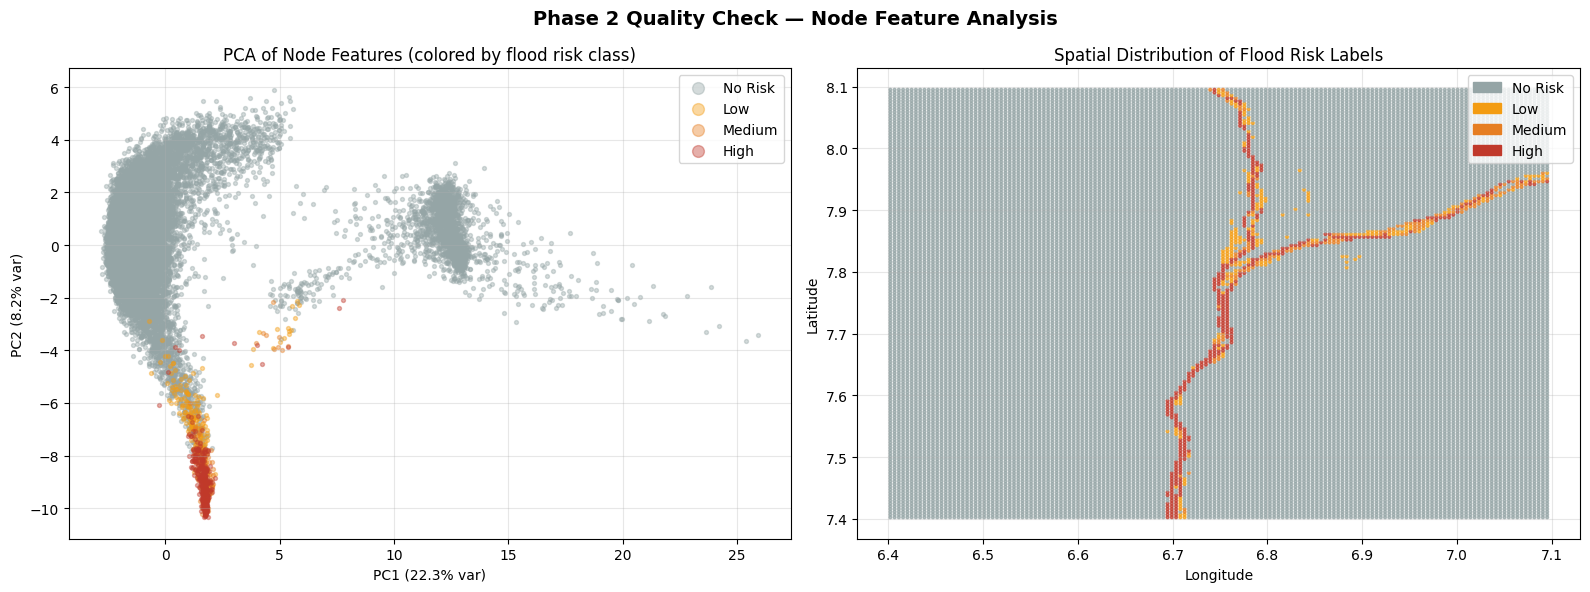


✅ PCA variance explained by 2 components: 30.5%
   (Higher = better class separability in feature space)


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

# ---- PCA of node features to verify class separability ----
valid_X = X[valid_mask]
valid_y = y[valid_mask]

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(valid_X)

class_colors = {0: '#95a5a6', 1: '#f39c12', 2: '#e67e22', 3: '#c0392b'}
class_names  = {0: 'No Risk', 1: 'Low', 2: 'Medium', 3: 'High'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phase 2 Quality Check — Node Feature Analysis', fontsize=14, fontweight='bold')

# PCA scatter
ax = axes[0]
for cls in [0, 1, 2, 3]:
    mask_cls = valid_y == cls
    if mask_cls.sum() > 0:
        ax.scatter(X_pca[mask_cls, 0], X_pca[mask_cls, 1],
                   c=class_colors[cls], label=class_names[cls],
                   alpha=0.4, s=8, rasterized=True)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('PCA of Node Features (colored by flood risk class)')
ax.legend(markerscale=3, fontsize=10)
ax.grid(True, alpha=0.3)

# Spatial map of labels
ax2 = axes[1]
lons = nodes_gdf.loc[valid_mask, 'centroid_lon'].values
lats = nodes_gdf.loc[valid_mask, 'centroid_lat'].values
colors_plot = [class_colors[c] for c in valid_y]
sc = ax2.scatter(lons, lats, c=colors_plot, s=4, alpha=0.7, rasterized=True)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_title('Spatial Distribution of Flood Risk Labels')
patches = [mpatches.Patch(color=class_colors[c], label=class_names[c]) for c in range(4)]
ax2.legend(handles=patches, fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/phase2_quality_check.png', dpi=150, bbox_inches='tight')
plt.show()

var_explained = pca.explained_variance_ratio_.sum() * 100
print(f'\n✅ PCA variance explained by 2 components: {var_explained:.1f}%')
print(f'   (Higher = better class separability in feature space)')

## ✅ Phase 2 Complete!

**What we built:**
- ✅ Loaded 19-band GeoTIFF from GEE (Phase 1 output)
- ✅ Modified ResNet18 encoder for 18-channel satellite input
- ✅ Extracted 64×64 tile patches for all graph nodes
- ✅ CNN inference → 256-dim embedding per node
- ✅ Concatenated with normalized spectral features → 274-dim
- ✅ Added spatial coordinates → **276-dim final node features**
- ✅ Spatial train/val/test split (no leakage)
- ✅ PyG `Data` object ready for Graph Attention Network

**Saved files:**
```
Google Drive/GeoAI_Kogi/
  kogi_pyg_data.pt    ← PyG graph with node features + labels + masks
  kogi_encoder.pth    ← ResNet18 encoder weights
  kogi_scaler.pkl     ← Feature scaler (for inference)
```

**Next → Phase 3: Graph Attention Network (GAT)**
```
Phase 1 ✅ → Phase 2 ✅ → Phase 3: GAT → Phase 4: Transformer → Phase 5: Maps
```
